# K-Pick 재구매 예측 모델 학습
**데이터**: `data/prep/k-pick_total_v3.csv` | **타깃**: `label` (1=재구매, 0=미구매)

---
## 1. 데이터 로드

In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font = fm.FontProperties(fname='C:/Windows/Fonts/malgun.ttf')
plt.rcParams['font.family'] = font.get_name()
plt.rcParams['axes.unicode_minus'] = False
RANDOM_STATE = 42

# ── 1.1 학습 데이터 추출 ─────────────────────────────────
df = pd.read_csv('../data/prep/k-pick_total_v3.csv')
print('데이터 크기:', df.shape)
print('\nLabel 분포:')
print(df['label'].value_counts())
print(f'양성 비율: {df["label"].mean():.4f}')

# ── 1.2 사용하지 않는 피처 제외 및 정답 데이터 분리 ─────
DROP_COLS    = ['user_id', 'product_id', 'order_id', 'label']
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

X = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())
y = df['label']

print(f'\n피처 수: {len(FEATURE_COLS)}')
print('피처 목록:', FEATURE_COLS)

# ── 1.3 스케일링 준비 (정규화) ───────────────────────────
# train 데이터에만 fit → val/test에는 transform만 적용 (데이터 누수 방지)
scaler = StandardScaler()

# ── 1.4 학습용(train) / 검증용(val) / 테스트(test) 분리 (7:2:1) ──
# 1단계: 전체 → train+val (90%) / test (10%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.1, random_state=RANDOM_STATE, stratify=y
)
# 2단계: train+val (90%) → train 70% / val 20%  │  val 비율 = 2/9 ≈ 0.222
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=2/9, random_state=RANDOM_STATE, stratify=y_trainval
)

# 스케일러 적용 (Logistic Regression 전용)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f'\n학습 세트:   {X_train.shape}  | Label 분포: {y_train.mean():.4f}')
print(f'검증 세트:   {X_val.shape}    | Label 분포: {y_val.mean():.4f}')
print(f'테스트 세트: {X_test.shape}   | Label 분포: {y_test.mean():.4f}')
print('\n스케일링 완료')

데이터 크기: (8474661, 30)

Label 분포:
label
0    7645837
1     828824
Name: count, dtype: int64
양성 비율: 0.0978

피처 수: 26
피처 목록: ['order_dow', 'order_hour_of_day', 'days_since_prior_order', 'up_order_count', 'up_reordered_sum', 'up_avg_add_to_cart', 'up_reorder_rate', 'up_user_product_preference', 'up_first_cart_rate', 'up_cart_top5_rate', 'up_recency', 'aisle_id', 'department_id', 'user_total_orders', 'user_avg_days_between', 'user_std_days_between', 'user_total_items', 'user_distinct_items', 'user_reorder_ratio', 'favorite_dow', 'favorite_hour', 'prod_reorder_rate', 'prod_avg_cart_pos', 'prod_total_sales', 'prod_reorder_times', 'prod_unique_users']

학습 세트:   (5932262, 26)  | Label 분포: 0.0978
검증 세트:   (1694932, 26)    | Label 분포: 0.0978
테스트 세트: (847467, 26)   | Label 분포: 0.0978

스케일링 완료


---
## 2. 모델 객체 생성

Logistic Regression 학습 완료
[0]	validation_0-auc:0.79153
[100]	validation_0-auc:0.83191
[200]	validation_0-auc:0.83327
[300]	validation_0-auc:0.83398
[400]	validation_0-auc:0.83446
[500]	validation_0-auc:0.83483
[600]	validation_0-auc:0.83512
[700]	validation_0-auc:0.83536
[800]	validation_0-auc:0.83554
[900]	validation_0-auc:0.83574
[999]	validation_0-auc:0.83589
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.832622
[200]	valid_0's auc: 0.833707
[300]	valid_0's auc: 0.83438
[400]	valid_0's auc: 0.834807
[500]	valid_0's auc: 0.835143
[600]	valid_0's auc: 0.835418
[700]	valid_0's auc: 0.835629
[800]	valid_0's auc: 0.835835
[900]	valid_0's auc: 0.835986
[1000]	valid_0's auc: 0.836137
Did not meet early stopping. Best iteration is:
[994]	valid_0's auc: 0.836138

모델                         Train Acc    Val Acc
---------------------------------------------
Logistic Regression           0.7502     0.7502
XGBoost                       0.7614     0.7598
Light

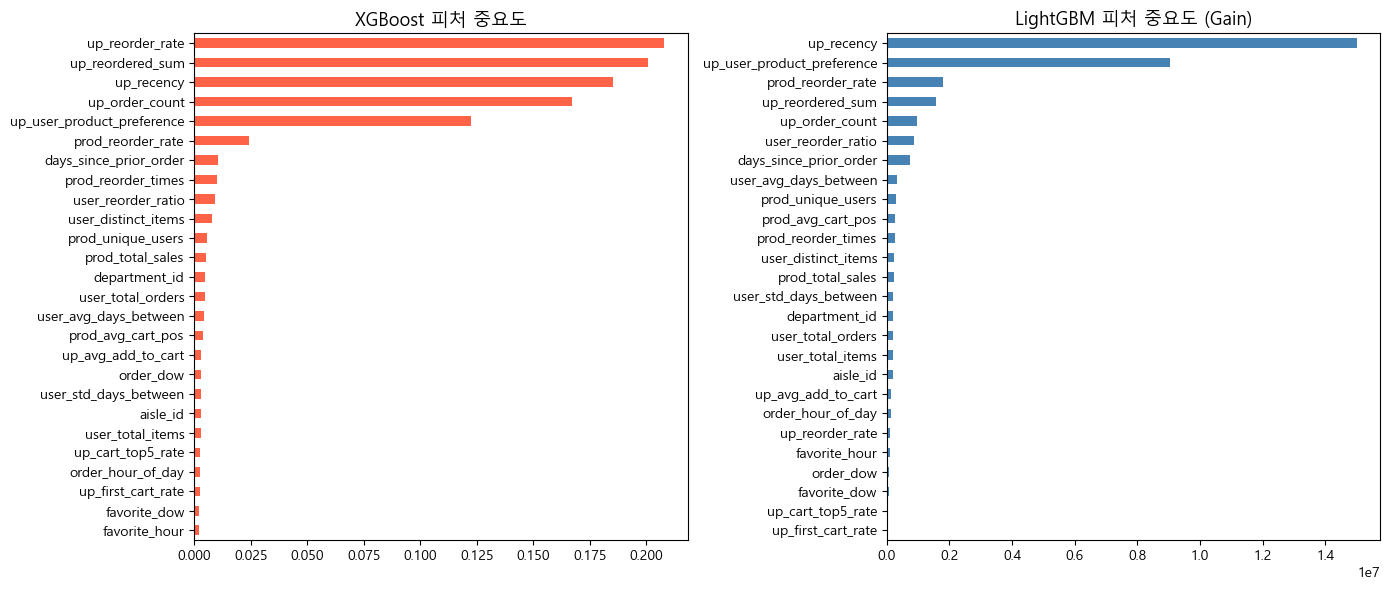

In [6]:
# ── 2.1 모델 학습 시작 (model.fit()) ─────────────────────

# --- Logistic Regression ---
# 대용량 데이터 → 최대 50만 샘플 추출 후 학습
sample_n   = min(500_000, len(X_train))
sample_pos = np.random.RandomState(RANDOM_STATE).choice(len(X_train), sample_n, replace=False)

lr_model = LogisticRegression(
    C=1.0, max_iter=300, class_weight='balanced',
    solver='saga', random_state=RANDOM_STATE, n_jobs=-1
)
lr_model.fit(X_train_scaled[sample_pos], y_train.iloc[sample_pos])
print('Logistic Regression 학습 완료')

# --- XGBoost ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=6,
    min_child_weight=30, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist', eval_metric='auc',
    early_stopping_rounds=50,
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

# --- LightGBM ---
lgb_model = lgb.train(
    params={
        'objective': 'binary', 'metric': 'auc',
        'learning_rate': 0.05, 'num_leaves': 63, 'max_depth': 7,
        'min_child_samples': 30, 'feature_fraction': 0.8,
        'bagging_fraction': 0.8, 'bagging_freq': 5,
        'lambda_l1': 0.1, 'lambda_l2': 0.1,
        'is_unbalance': True, 'verbose': -1, 'seed': RANDOM_STATE,
    },
    train_set=lgb.Dataset(X_train, label=y_train),
    num_boost_round=1000,
    valid_sets=[lgb.Dataset(X_val, label=y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

# ── 2.2 학습 세트, 검증 세트 정확도 ─────────────────────
lr_train_acc  = accuracy_score(y_train, lr_model.predict(X_train_scaled))
lr_val_acc    = accuracy_score(y_val,   lr_model.predict(X_val_scaled))
xgb_train_acc = accuracy_score(y_train, xgb_model.predict(X_train))
xgb_val_acc   = accuracy_score(y_val,   xgb_model.predict(X_val))
lgb_train_acc = accuracy_score(y_train, (lgb_model.predict(X_train) >= 0.5).astype(int))
lgb_val_acc   = accuracy_score(y_val,   (lgb_model.predict(X_val)   >= 0.5).astype(int))

print('\n{:<25} {:>10} {:>10}'.format('모델', 'Train Acc', 'Val Acc'))
print('-' * 45)
for name, tr, vl in [('Logistic Regression', lr_train_acc, lr_val_acc),
                     ('XGBoost',             xgb_train_acc, xgb_val_acc),
                     ('LightGBM',            lgb_train_acc, lgb_val_acc)]:
    print('{:<25} {:>10.4f} {:>10.4f}'.format(name, tr, vl))

# ── 2.3 각 feature들의 계수 확인 (Logistic Regression) ──
coef_series = pd.Series(lr_model.coef_[0], index=FEATURE_COLS).sort_values(ascending=False)
print('\n[ LR 계수 - 재구매 예측에 대한 영향도 ]')
print('▶ 상위 10 (재구매에 긍정 영향):')
print(coef_series.head(10).to_string())
print('\n▶ 하위 10 (재구매에 부정 영향):')
print(coef_series.tail(10).to_string())

dup_coef = coef_series[coef_series.duplicated(keep=False)]
if not dup_coef.empty:
    print('\n▶ 중복 계수값을 가진 피처:')
    print(dup_coef.sort_values().to_string())
else:
    print('\n중복 계수값 없음')

# ── 2.4 각 feature들의 중요도 확인 ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS) \
  .sort_values(ascending=True) \
  .plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('XGBoost 피처 중요도', fontsize=13)

pd.Series(lgb_model.feature_importance(importance_type='gain'), index=FEATURE_COLS) \
  .sort_values(ascending=True) \
  .plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('LightGBM 피처 중요도 (Gain)', fontsize=13)

plt.tight_layout()
plt.show()

---
## 3. 성능 평가

=== 모델 성능 비교 (테스트 세트 기준) ===
                     Accuracy  F1 Score     AUC
모델                                             
Logistic Regression    0.7514    0.3668  0.8221
XGBoost                0.7606    0.3810  0.8368
LightGBM               0.7601    0.3809  0.8371

[Logistic Regression]
              precision    recall  f1-score   support

      미구매(0)       0.96      0.75      0.85    764585
      재구매(1)       0.24      0.74      0.37     82882

    accuracy                           0.75    847467
   macro avg       0.60      0.74      0.61    847467
weighted avg       0.89      0.75      0.80    847467


[XGBoost]
              precision    recall  f1-score   support

      미구매(0)       0.97      0.76      0.85    764585
      재구매(1)       0.25      0.75      0.38     82882

    accuracy                           0.76    847467
   macro avg       0.61      0.76      0.62    847467
weighted avg       0.90      0.76      0.81    847467


[LightGBM]
              precision    reca

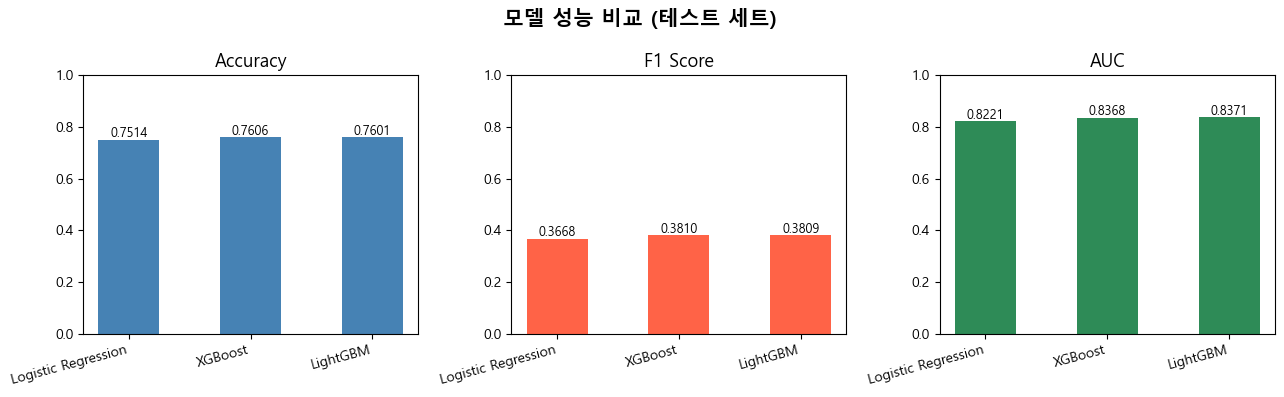

In [7]:
# ── 3.1 정확도, F1-Score 등 결과 출력 ────────────────────

# 테스트 세트 예측
lr_test_pred  = lr_model.predict(X_test_scaled)
lr_test_prob  = lr_model.predict_proba(X_test_scaled)[:, 1]

xgb_test_pred = xgb_model.predict(X_test)
xgb_test_prob = xgb_model.predict_proba(X_test)[:, 1]

lgb_test_prob = lgb_model.predict(X_test)
lgb_test_pred = (lgb_test_prob >= 0.5).astype(int)

# 성능 비교표
results = pd.DataFrame({
    '모델': ['Logistic Regression', 'XGBoost', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_test, lr_test_pred),
        accuracy_score(y_test, xgb_test_pred),
        accuracy_score(y_test, lgb_test_pred),
    ],
    'F1 Score': [
        f1_score(y_test, lr_test_pred),
        f1_score(y_test, xgb_test_pred),
        f1_score(y_test, lgb_test_pred),
    ],
    'AUC': [
        roc_auc_score(y_test, lr_test_prob),
        roc_auc_score(y_test, xgb_test_prob),
        roc_auc_score(y_test, lgb_test_prob),
    ],
}).set_index('모델')

print('=== 모델 성능 비교 (테스트 세트 기준) ===')
print(results.round(4))

# 상세 분류 보고서
for name, pred in [('Logistic Regression', lr_test_pred),
                   ('XGBoost',             xgb_test_pred),
                   ('LightGBM',            lgb_test_pred)]:
    print(f'\n[{name}]')
    print(classification_report(y_test, pred, target_names=['미구매(0)', '재구매(1)']))

# 성능 비교 그래프
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (metric, color) in zip(axes, [('Accuracy', 'steelblue'), ('F1 Score', 'tomato'), ('AUC', 'seagreen')]):
    ax.bar(results.index, results[metric], color=color, width=0.5)
    ax.set_title(metric, fontsize=13)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(results.index, rotation=15, ha='right')
    for i, v in enumerate(results[metric]):
        ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)
plt.suptitle('모델 성능 비교 (테스트 세트)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. 구매 시점 예측
> 재구매 여부를 넘어 **다음 구매까지 걸리는 일수**를 4개 구간으로 분류합니다.
>
> | 구간 | 의미 |
> |------|------|
> | `~7일` | 단기 재구매자 |
> | `8~14일` | 격주 구매자 |
> | `15~30일` | 월 단위 구매자 |
> | `31일+` | 비정기 구매자 |

=== 구매 시점 분포 ===
  [0] ~7일: 37,346명  (28.5%)
  [1] 8~14일: 26,368명  (20.1%)
  [2] 15~30일: 67,495명  (51.4%)
  [3] 31일+: 0명  (0.0%)
  합계: 131,209명

Training until validation scores don't improve for 30 rounds
[100]	valid_0's multi_logloss: 0.870471
Early stopping, best iteration is:
[110]	valid_0's multi_logloss: 0.870425
[구매 시점 예측] Accuracy: 0.6220

              precision    recall  f1-score   support

         ~7일       0.59      0.53      0.56      7469
       8~14일       0.43      0.03      0.06      5274
      15~30일       0.64      0.90      0.75     13499
        31일+       0.00      0.00      0.00         0

    accuracy                           0.62     26242
   macro avg       0.41      0.37      0.34     26242
weighted avg       0.58      0.62      0.56     26242



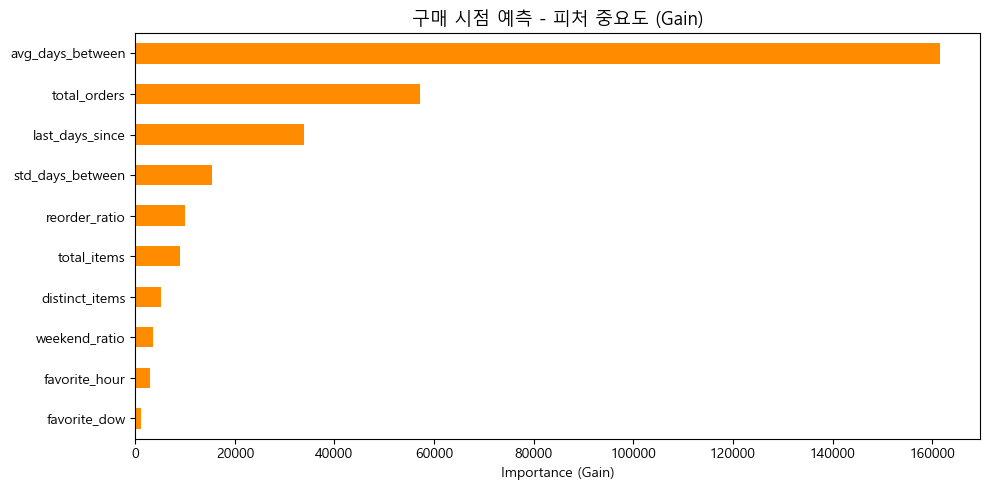

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb

# 한글 폰트
font = fm.FontProperties(fname='C:/Windows/Fonts/malgun.ttf')
plt.rcParams['font.family'] = font.get_name()
plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 42
TIMING_LABELS = ['~7일', '8~14일', '15~30일', '31일+']

# ── 4.1 raw 데이터 로드 ───────────────────────────────────
orders_raw  = pd.read_csv('../data/raw/orders.csv')
prior_prods = pd.read_csv('../data/raw/order_products__prior.csv')

prior_ord = orders_raw[orders_raw['eval_set'] == 'prior'].copy()
train_ord = orders_raw[orders_raw['eval_set'] == 'train'].copy()

# ── 4.2 유저 피처 구성 (prior 주문 기반) ─────────────────
user_feat = prior_ord.groupby('user_id').agg(
    total_orders     = ('order_number',          'max'),
    avg_days_between = ('days_since_prior_order', 'mean'),
    std_days_between = ('days_since_prior_order', 'std'),
    last_days_since  = ('days_since_prior_order', 'last'),
    favorite_dow     = ('order_dow',              lambda x: x.mode()[0]),
    favorite_hour    = ('order_hour_of_day',      lambda x: x.mode()[0]),
    weekend_ratio    = ('order_dow',              lambda x: x.isin([0, 6]).mean()),
).reset_index()

prior_merged = prior_prods.merge(prior_ord[['order_id', 'user_id']], on='order_id')
user_item = prior_merged.groupby('user_id').agg(
    total_items    = ('product_id', 'count'),
    distinct_items = ('product_id', 'nunique'),
    reorder_ratio  = ('reordered',  'mean'),
).reset_index()

user_feat = user_feat.merge(user_item, on='user_id')
user_feat['std_days_between'] = user_feat['std_days_between'].fillna(0)

# ── 4.3 타깃 생성: 다음 구매까지 걸리는 일수 → 4구간 ────
timing_target = (
    train_ord[['user_id', 'days_since_prior_order']]
    .dropna()
    .rename(columns={'days_since_prior_order': 'days_to_next'})
)

df_timing = user_feat.merge(timing_target, on='user_id', how='inner')

df_timing['timing_label'] = pd.cut(
    df_timing['days_to_next'],
    bins=[0, 7, 14, 30, float('inf')],
    labels=[0, 1, 2, 3],
    include_lowest=True
).astype(int)

print('=== 구매 시점 분포 ===')
total = len(df_timing)
for i, lbl in enumerate(TIMING_LABELS):
    n = (df_timing['timing_label'] == i).sum()
    print(f'  [{i}] {lbl}: {n:,}명  ({n / total * 100:.1f}%)')
print(f'  합계: {total:,}명\n')

# ── 4.4 모델 학습 (LightGBM 다중 분류) ───────────────────
FEATS = [
    'total_orders', 'avg_days_between', 'std_days_between', 'last_days_since',
    'favorite_dow', 'favorite_hour', 'weekend_ratio',
    'total_items', 'distinct_items', 'reorder_ratio',
]

X_t = df_timing[FEATS].fillna(0).values
y_t = df_timing['timing_label'].values

X_tr, X_vl, y_tr, y_vl = train_test_split(
    X_t, y_t, test_size=0.2, stratify=y_t, random_state=RANDOM_STATE
)

timing_model = lgb.train(
    params={
        'objective':         'multiclass',
        'num_class':         4,
        'metric':            'multi_logloss',
        'learning_rate':     0.05,
        'num_leaves':        31,
        'max_depth':         6,
        'min_child_samples': 20,
        'feature_fraction':  0.8,
        'bagging_fraction':  0.8,
        'bagging_freq':      5,
        'is_unbalance':      True,
        'verbose':           -1,
        'seed':              RANDOM_STATE,
    },
    train_set=lgb.Dataset(X_tr, label=y_tr),
    num_boost_round=500,
    valid_sets=[lgb.Dataset(X_vl, label=y_vl)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(100)]
)

# ── 4.5 성능 평가 ────────────────────────────────────────
y_pred = timing_model.predict(X_vl).argmax(axis=1)
acc = accuracy_score(y_vl, y_pred)
print(f'[구매 시점 예측] Accuracy: {acc:.4f}\n')
print(classification_report(
    y_vl, y_pred,
    labels=[0, 1, 2, 3],
    target_names=TIMING_LABELS,
    zero_division=0
))

# ── 4.6 피처 중요도 시각화 ───────────────────────────────
importance = pd.Series(
    timing_model.feature_importance(importance_type='gain'),
    index=FEATS
).sort_values(ascending=True)

importance.plot(kind='barh', figsize=(10, 5), color='darkorange')
plt.title('구매 시점 예측 - 피처 중요도 (Gain)', fontsize=13)
plt.xlabel('Importance (Gain)')
plt.tight_layout()
plt.show()


---
## 5. 공동 구매 패턴 분석 (FP-Growth)
> 상품을 독립적으로 예측하는 것을 넘어 **함께 자주 구매되는 상품 조합**을 발굴합니다.
>
> - **Support**: 전체 주문 중 해당 조합이 등장하는 비율
> - **Confidence**: A를 샀을 때 B도 살 확률
> - **Lift**: 우연 대비 연관성 강도 (1 초과 → 의미 있는 조합)

분석 대상 주문: 2,553,298건  |  상품 수: 200개

빈번 아이템셋: 162개
연관 규칙 (lift ≥ 1.5): 30개

[ 상위 20개 연관 규칙 - Lift 기준 ]
                        antecedents                         consequents  support  confidence     lift
                 frozenset({Limes})            frozenset({Large Lemon}) 0.010732    0.194863 3.259224
           frozenset({Large Lemon})                  frozenset({Limes}) 0.010732    0.179507 3.259224
  frozenset({Organic Strawberries})    frozenset({Organic Raspberries}) 0.013262    0.127938 2.383415
   frozenset({Organic Raspberries})   frozenset({Organic Strawberries}) 0.013262    0.247072 2.383415
  frozenset({Organic Hass Avocado})    frozenset({Organic Raspberries}) 0.010102    0.120763 2.249746
   frozenset({Organic Raspberries})   frozenset({Organic Hass Avocado}) 0.010102    0.188192 2.249746
    frozenset({Organic Fuji Apple})                 frozenset({Banana}) 0.013294    0.378693 2.046101
                frozenset({Banana})     frozenset({Organic Fuji Apple}) 0.013294 

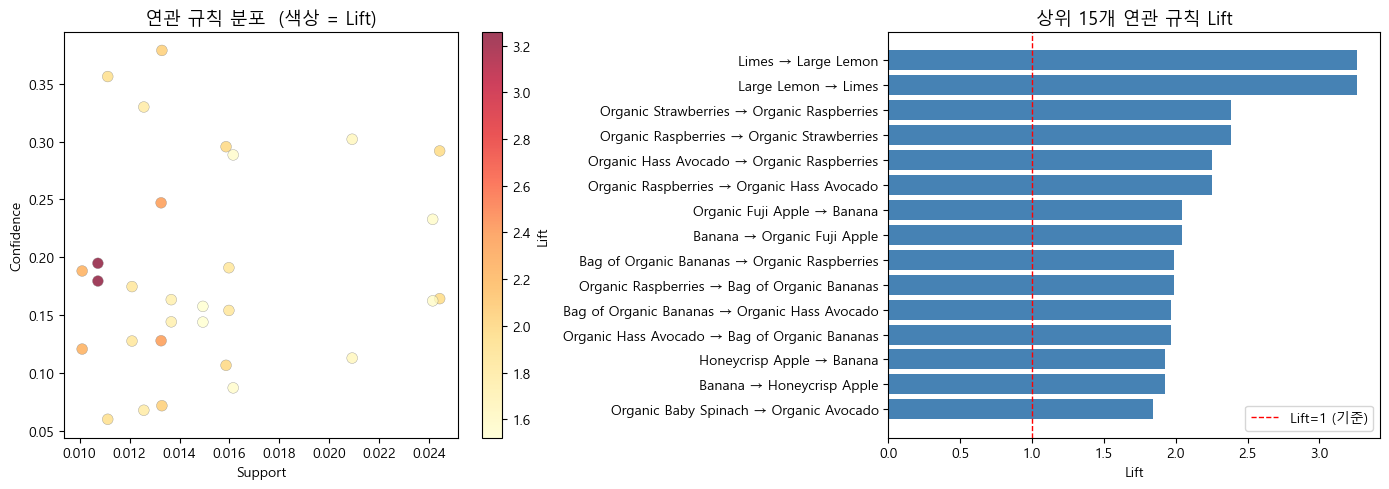

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# mlxtend 없으면 자동 설치 (pip install mlxtend)
try:
    from mlxtend.frequent_patterns import fpgrowth, association_rules
    from mlxtend.preprocessing import TransactionEncoder
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'mlxtend', '-q'])
    from mlxtend.frequent_patterns import fpgrowth, association_rules
    from mlxtend.preprocessing import TransactionEncoder

# ── 5.1 상품명 매핑 (products.csv 있으면 상품명, 없으면 ID) ─
try:
    products = pd.read_csv('../data/raw/products.csv')
    id2name  = products.set_index('product_id')['product_name'].to_dict()
    has_names = True
except FileNotFoundError:
    has_names = False
    print('products.csv 없음 → product_id로 표시합니다')

# ── 5.2 바구니 데이터 구성 ───────────────────────────────
# 섹션 4에서 prior_prods 이미 로드됨, 없으면 다시 로드
try:
    prior_prods
except NameError:
    prior_prods = pd.read_csv('../data/raw/order_products__prior.csv')

TOP_N = 200
top_prod_ids = prior_prods['product_id'].value_counts().head(TOP_N).index
prior_top    = prior_prods[prior_prods['product_id'].isin(top_prod_ids)].copy()

if has_names:
    prior_top['product_id'] = prior_top['product_id'].map(id2name)

baskets = prior_top.groupby('order_id')['product_id'].apply(list).tolist()
print(f'분석 대상 주문: {len(baskets):,}건  |  상품 수: {TOP_N}개')

# ── 5.3 FP-Growth 실행 ───────────────────────────────────
te        = TransactionEncoder()
te_array  = te.fit_transform(baskets)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

freq_itemsets = fpgrowth(basket_df, min_support=0.01, use_colnames=True)
rules = association_rules(freq_itemsets, metric='lift', min_threshold=1.5)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'\n빈번 아이템셋: {len(freq_itemsets)}개')
print(f'연관 규칙 (lift ≥ 1.5): {len(rules)}개')

# ── 5.4 상위 규칙 출력 ───────────────────────────────────
print('\n[ 상위 20개 연관 규칙 - Lift 기준 ]')
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20).to_string(index=False))

# ── 5.5 시각화 ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='YlOrRd', s=60, alpha=0.75,
    edgecolors='grey', linewidth=0.3
)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('연관 규칙 분포  (색상 = Lift)', fontsize=13)

top15 = rules.head(15).copy()
top15['rule'] = top15.apply(
    lambda r: '{} → {}'.format(
        ', '.join(list(r['antecedents']))[:25],
        ', '.join(list(r['consequents']))[:25]
    ), axis=1
)
axes[1].barh(top15['rule'][::-1], top15['lift'][::-1], color='steelblue')
axes[1].axvline(x=1, color='red', linestyle='--', linewidth=1, label='Lift=1 (기준)')
axes[1].set_xlabel('Lift')
axes[1].set_title('상위 15개 연관 규칙 Lift', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()